# Prepare notebook

In [9]:
from pathlib import Path
import scanpy as sc
import scvi
import seaborn as sns
import torch
import matplotlib.pyplot as plt
from cytetype import CyteType

In [ ]:
scvi.settings.seed = 0
torch.set_float32_matmul_precision("high")
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

Seed set to 0


# Process data and train model
Pipeline in `./scripts/train_scvi.py`

## Load raw data and process

In [17]:
# Load data
adata = sc.read(
    filename=Path.cwd().parent / "data" / "monocyte_dendritic.h5ad",
    backup_url=(
        "https://datasets.cellxgene.cziscience.com/c2068d3f-87e7-4a0e-9795-4dae11bcb9ac.h5ad"
    ),
)
adata

AnnData object with n_obs × n_vars = 389187 × 18063
    obs: 'cohort.cohortGuid', 'subject.subjectGuid', 'sample.sampleKitGuid', 'specimen.specimenGuid', 'subject.ageAtFirstDraw', 'subject.race', 'subject.ethnicity', 'subject.cmv', 'sample.visitName', 'sample.subjectAgeAtDraw', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_reads', 'n_umis', 'n_genes', 'total_counts_mito', 'pct_counts_mito', 'doublet_score', 'AIFI_L1', 'predicted_AIFI_L1', 'AIFI_L2', 'predicted_AIFI_L2', 'AIFI_L3', 'predicted_AIFI_L3', 'tissue_ontology_term_id', 'tissue_type', 'suspension_type', 'assay_ontology_term_id', 'sex_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feat

In [20]:
# Save raw counts to `counts` layer in anndata object
adata.layers["counts"] = adata.raw.X.copy()

In [24]:
# Filter genes that appear in few cells
sc.pp.filter_genes(adata, min_counts=10)

In [25]:
# Normalize cells to 10,000 counts
sc.pp.normalize_total(adata, target_sum=1e4)

# Change to log scale
sc.pp.log1p(adata)

In [26]:
# Perform feature selection
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=1500,
    subset=True,
    layer="counts",
    flavor="seurat_v3",
    batch_key="batch_id",
)

In [32]:
# Setup anndata object for model fitting
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    categorical_covariate_keys=["well_id"],
    continuous_covariate_keys=["pct_counts_mito"]
)

## Train scVI model

In [35]:
# Instantiate model
model = scvi.model.SCVI(adata)

# Train model
model.train(train_size=0.8, check_val_every_n_epoch=1)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/inf-33-2025/Work/Nygen/Interview/.venv/lib64/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/inf-33-2025/Work/Nygen/Interview/.venv/lib64/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=255` in the `DataLoader` to improve performance.
/home/inf-33-2025/Work/Nygen/Interview/.venv/lib64/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_co

Epoch 21/21: 100%|██████████| 21/21 [1:23:23<00:00, 233.80s/it, v_num=1, train_loss=636]

`Trainer.fit` stopped: `max_epochs=21` reached.


Epoch 21/21: 100%|██████████| 21/21 [1:23:23<00:00, 238.26s/it, v_num=1, train_loss=636]


In [37]:
# Store model outputs in anndata object
adata.obsm["X_scVI"] = model.get_latent_representation()

## Save anndata to `h5ad` and model to `pt`

In [38]:
# Save filtered anndata object as new .h5ad file
adata.write_h5ad(
    Path.cwd().parent / "data" / "monocyte_dendritic_filter.h5ad"
)

In [39]:
# Save model
model.save(Path.cwd().parent / "models" / "scvi3", overwrite=True)

# Load preprocessed data and trained model

In [ ]:
# Load data
adata = sc.read(
    filename=Path.cwd().parent / "data" / "monocyte_dendritic_filter.h5ad"
)
adata

AnnData object with n_obs × n_vars = 389187 × 1500
    obs: 'cohort.cohortGuid', 'subject.subjectGuid', 'sample.sampleKitGuid', 'specimen.specimenGuid', 'subject.ageAtFirstDraw', 'subject.race', 'subject.ethnicity', 'subject.cmv', 'sample.visitName', 'sample.subjectAgeAtDraw', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_reads', 'n_umis', 'n_genes', 'total_counts_mito', 'pct_counts_mito', 'doublet_score', 'AIFI_L1', 'predicted_AIFI_L1', 'AIFI_L2', 'predicted_AIFI_L2', 'AIFI_L3', 'predicted_AIFI_L3', 'tissue_ontology_term_id', 'tissue_type', 'suspension_type', 'assay_ontology_term_id', 'sex_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', '_scvi_batch', '_scvi_labels'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_nam

In [5]:
# Load model
model = scvi.model.SCVI.load(Path.cwd().parent / "models" / "scvi3", adata=adata)

INFO     File /home/inf-33-2025/Work/Nygen/Interview/models/scvi2/model.pt already downloaded                      


/home/inf-33-2025/Work/Nygen/Interview/.venv/lib64/python3.12/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


# Plot model training diagnostics

In [42]:
# Assign model history to variable
hist = model.history


# Set matplotlib aesthetics
def plot_metric(train_key, val_key, title, ylabel):
    plt.figure(figsize=(6, 4))
    plt.plot(hist[train_key], label="train")
    plt.plot(hist[val_key], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

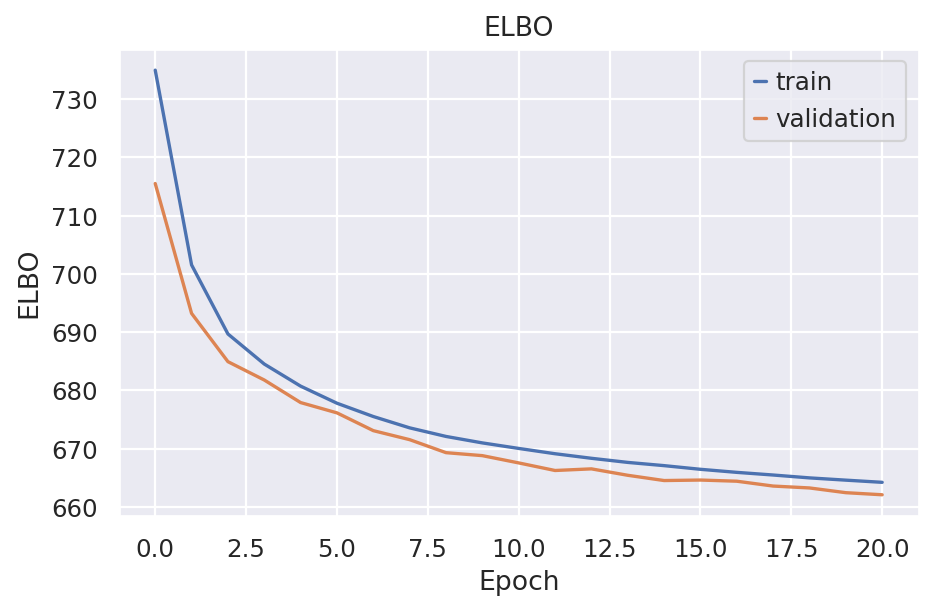

In [43]:
# Negative ELBO (Evidence lower bound)
if "elbo_train" in hist:
    plot_metric("elbo_train", "elbo_validation", "ELBO", "ELBO")

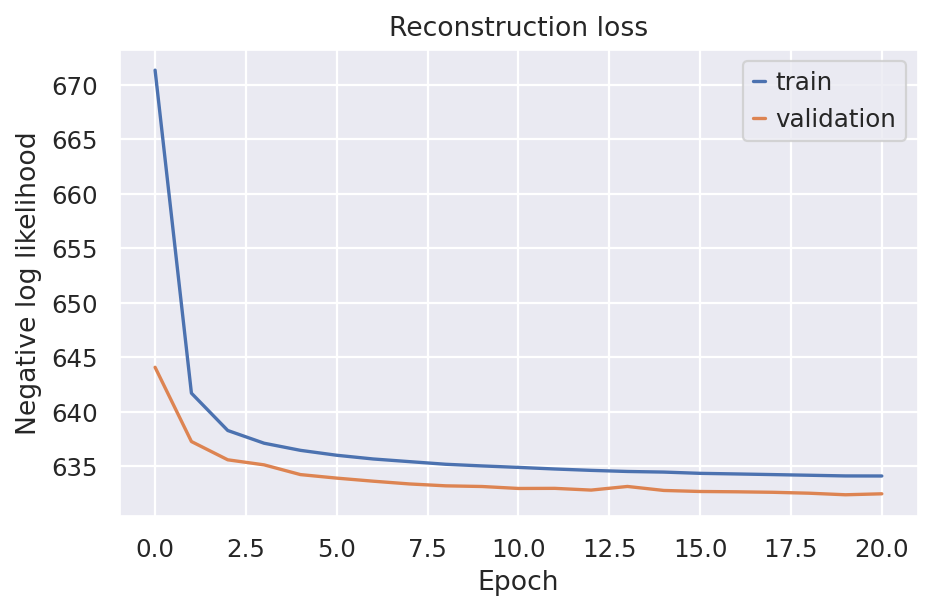

In [44]:
# Reconstruction loss
plot_metric(
    "reconstruction_loss_train",
    "reconstruction_loss_validation",
    "Reconstruction loss",
    "Negative log likelihood",
)

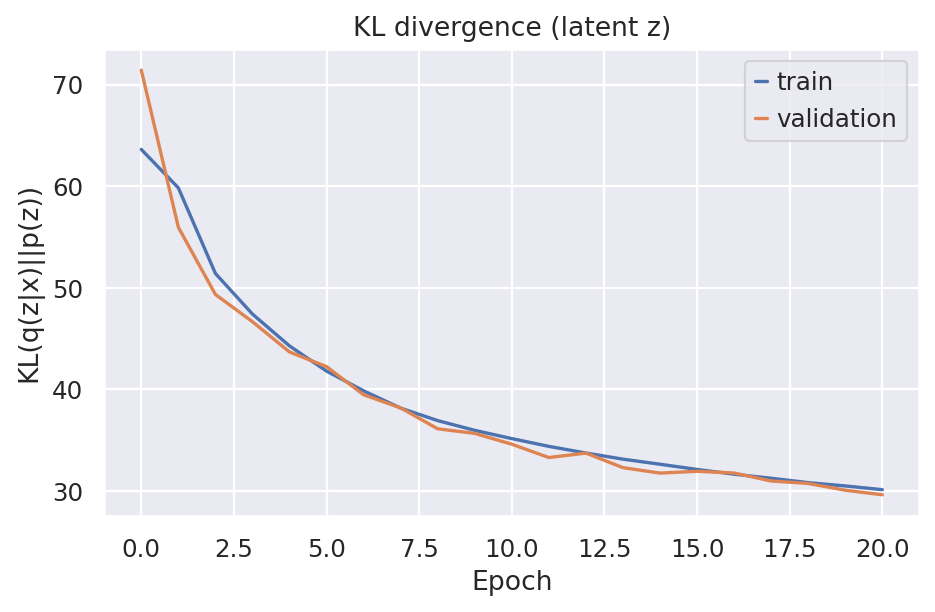

In [45]:
# Local KL divergence
plot_metric(
    "kl_local_train",
    "kl_local_validation",
    "KL divergence (latent z)",
    "KL(q(z|x)||p(z))",
)

# Cluster

In [ ]:
# Use scVI latent space for UMAP (batch correction)
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.umap(adata, min_dist=0.3)

SystemError: CPUDispatcher(<function nn_descent at 0x7fefdc509760>) returned a result with an exception set

In [ ]:
# Plot UMAP
sc.pl.umap(
    adata,
    color=["cell_type"],
    frameon=False,
)

# Run CyteType

In [ ]:
group_key = "clusters"
annotator = CyteType(
    adata, group_key=group_key, rank_key="rank_genes_" + group_key, n_top_genes=100
)
adata = annotator.run(study_context="Human PBMC from healthy donors 25-90")
sc.pl.umap(adata, color="cytetype_annotation_clusters")

# Compare CyteType annotations to annotations in dataset

In [ ]:
adata.obs[["cell_type", "cytetype_annotation"]].value_counts()